### 1. Loading of the Args ###

In [1]:
import pandas as pd
import numpy as np
import huggingface 
from time_moe.datasets.time_moe_dataset import TimeMoEDataset
from time_moe.datasets.time_moe_window_dataset import TimeMoEWindowDataset
import datetime
import os
import torch
import logging

for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)
    

# Configure logging
logging.basicConfig(    
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)

print(f"CWD: {os.getcwd()}")

# # Set which GPU(s) are visible
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"   # Use only GPU 1

# # Check what GPUs PyTorch sees
# print(f'Number of GPUs Available: {torch.cuda.device_count()}')  # should show 1 if you set "1"
# print(f'Device 0 Name: {torch.cuda.get_device_name(0)}')  # the GPU PyTorch will use


c:\Users\yinki\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CWD: c:\Users\yinki\OneDrive\NUS\BT4101\fyp-kiat\ML_Core\src


In [2]:
# Loading of config
from utils.utils import load_config, config_to_args

config_file_path = "../config/config_tickers_448_7_Channels_with_temporal_tape_v2.yaml"
config_dict = load_config(config_file_path)

place_holders_to_replace = {'version_name': config_dict['regression']['common']['version_name']}
args = config_to_args(config_dict, place_holders_to_replace)

print(f"Current Version Name: {args.regression.common.version_name}")

Current Version Name: tickers_448_7_Channels_with_temporal_tape_v2


### Overall Model Level Validation Outputs ###

2026-01-24 11:20:11 [INFO] Initializing S4 Model Validation Results..................
2026-01-24 11:20:11 [INFO] Loading saved sequences from ../data/outputs/tickers_448_7_Channels_with_temporal_tape_v2_all_inference_sequences.pkl
2026-01-24 11:20:49 [INFO] Loaded saved sequences from ../data/outputs/tickers_448_7_Channels_with_temporal_tape_v2_all_inference_sequences.pkl
2026-01-24 11:21:09 [INFO] Created validation DataFrame with 643680 rows
2026-01-24 11:21:09 [INFO] Created validation DataFrame (no dupe) with 83589 rows
2026-01-24 11:21:09 [INFO] Created validation DataFrame (no dupe, standardized) with 83589 rows
2026-01-24 11:21:10 [INFO] Calculating Regression Metrics at the aggregate dataframe Level..................
2026-01-24 11:21:17 [INFO] Plotting global residuals and error distribution... for 83589 sets of points


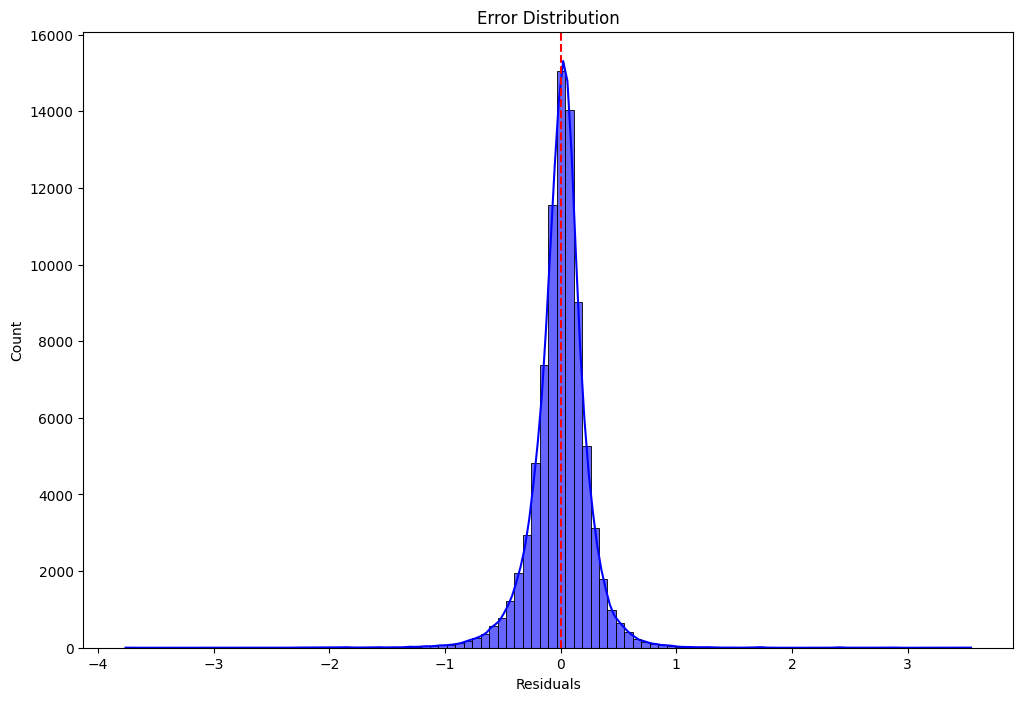

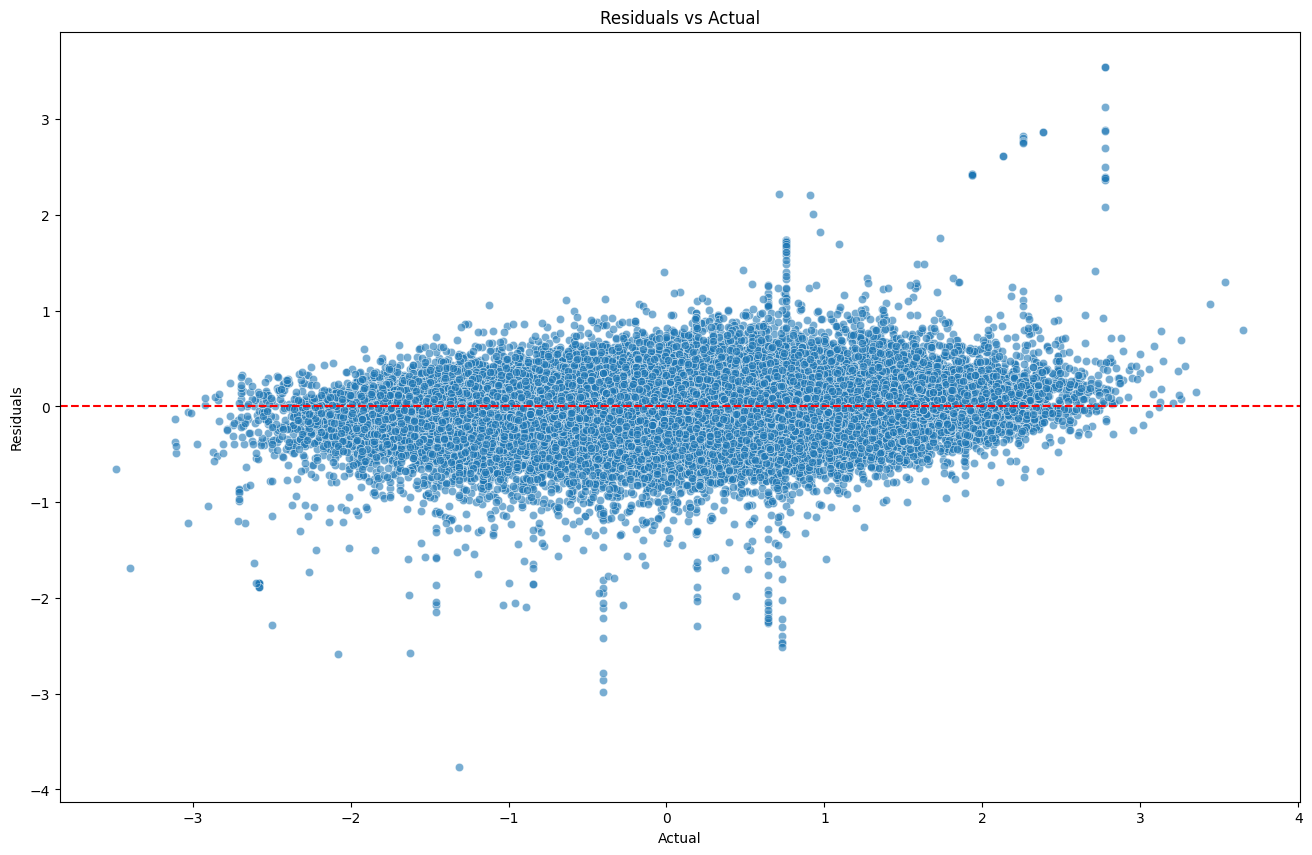

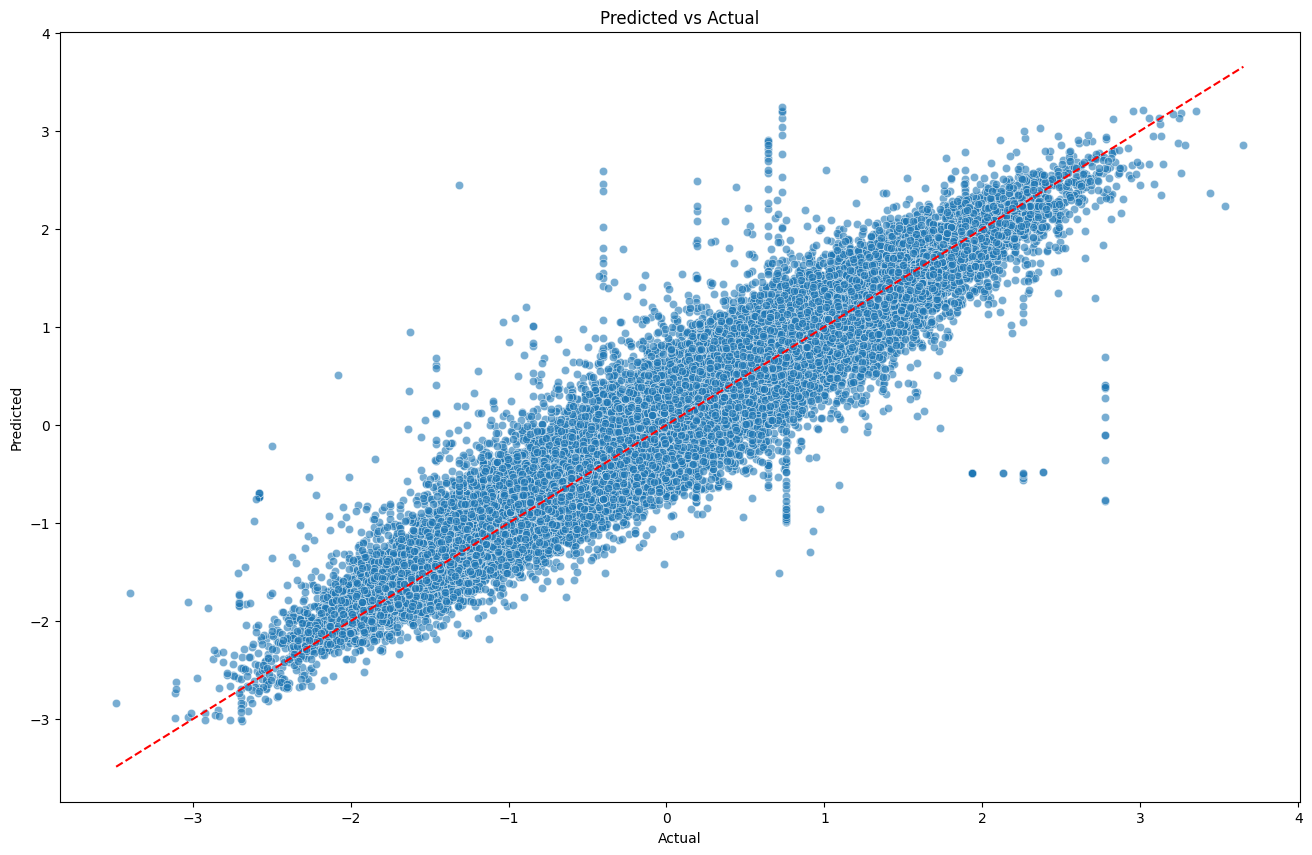

2026-01-24 11:21:20 [INFO] Top 5 tickers (lowest MAE): ['K', 'WMT', 'FICO', 'WELL', 'DLTR']
2026-01-24 11:21:20 [INFO] Bottom 5 tickers (highest MAE): ['QBEIF', 'ON', 'AVIJF', 'PBMRF', 'MAANF']
2026-01-24 11:21:20 [INFO] Calculating Regression Metrics at the sequence Level..................
2026-01-24 11:32:04 [INFO] Displaying Sequence Level Metrics for All


,Mean Squared Error,Root Mean Squared Error,Mean Absolute Error,Median Absolute Error,R² Score,Explained Variance,Bias (Mean Error),Mean Absolute Percentage Error,Symmetric Mean Absolute Percentage Error,Correlation,Standardized MSE,Standardized RMSE,Standardized MAE,Standardized Bias
count,80460.000000,80460.000000,80460.000000,80460.000000,80460.000000,80460.000000,80460.000000,80460.000000,80460.000000,64990.000000,79500.000000,79500.000000,79500.000000,79500.000000
missing,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15470.000000,960.000000,960.000000,960.000000,960.000000
missing_pct,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.226945,1.193139,1.193139,1.193139,1.193139
mean,137.540857,4.249686,3.545666,3.187634,-0.399939,-0.013392,1.575222,8.105478,2.054854,0.015343,1.406278,1.161300,0.962938,0.429971
std,1847.669646,10.930806,9.187465,8.539956,0.662405,0.169377,5.883219,226.607224,7.266195,0.573512,0.662865,0.240127,0.210445,0.454250
min,0.000000,0.000000,0.000000,0.000000,-7.937940,-2.865763,-0.000977,0.000000,0.000000,-1.000000,0.390717,0.625073,0.415768,-0.000027
25%,0.773269,0.879357,0.726332,0.611452,-0.583160,-0.073149,0.019518,0.886661,0.884079,-0.510178,1.000000,1.000000,0.830453,0.015922
median,3.489640,1.868058,1.547240,1.345001,-0.101256,0.000000,0.335245,1.323436,1.317051,0.029017,1.107486,1.052371,0.903123,0.275431
75%,16.566623,4.070212,3.379972,2.983885,0.000000,0.057441,1.302954,2.021285,2.004625,0.540180,1.592470,1.261931,1.038299,0.755552
max,123091.992188,350.844696,307.025940,337.094238,1.000000,1.000000,288.413513,18540.808594,197.812088,1.000000,8.937940,2.989639,2.573896,2.395985


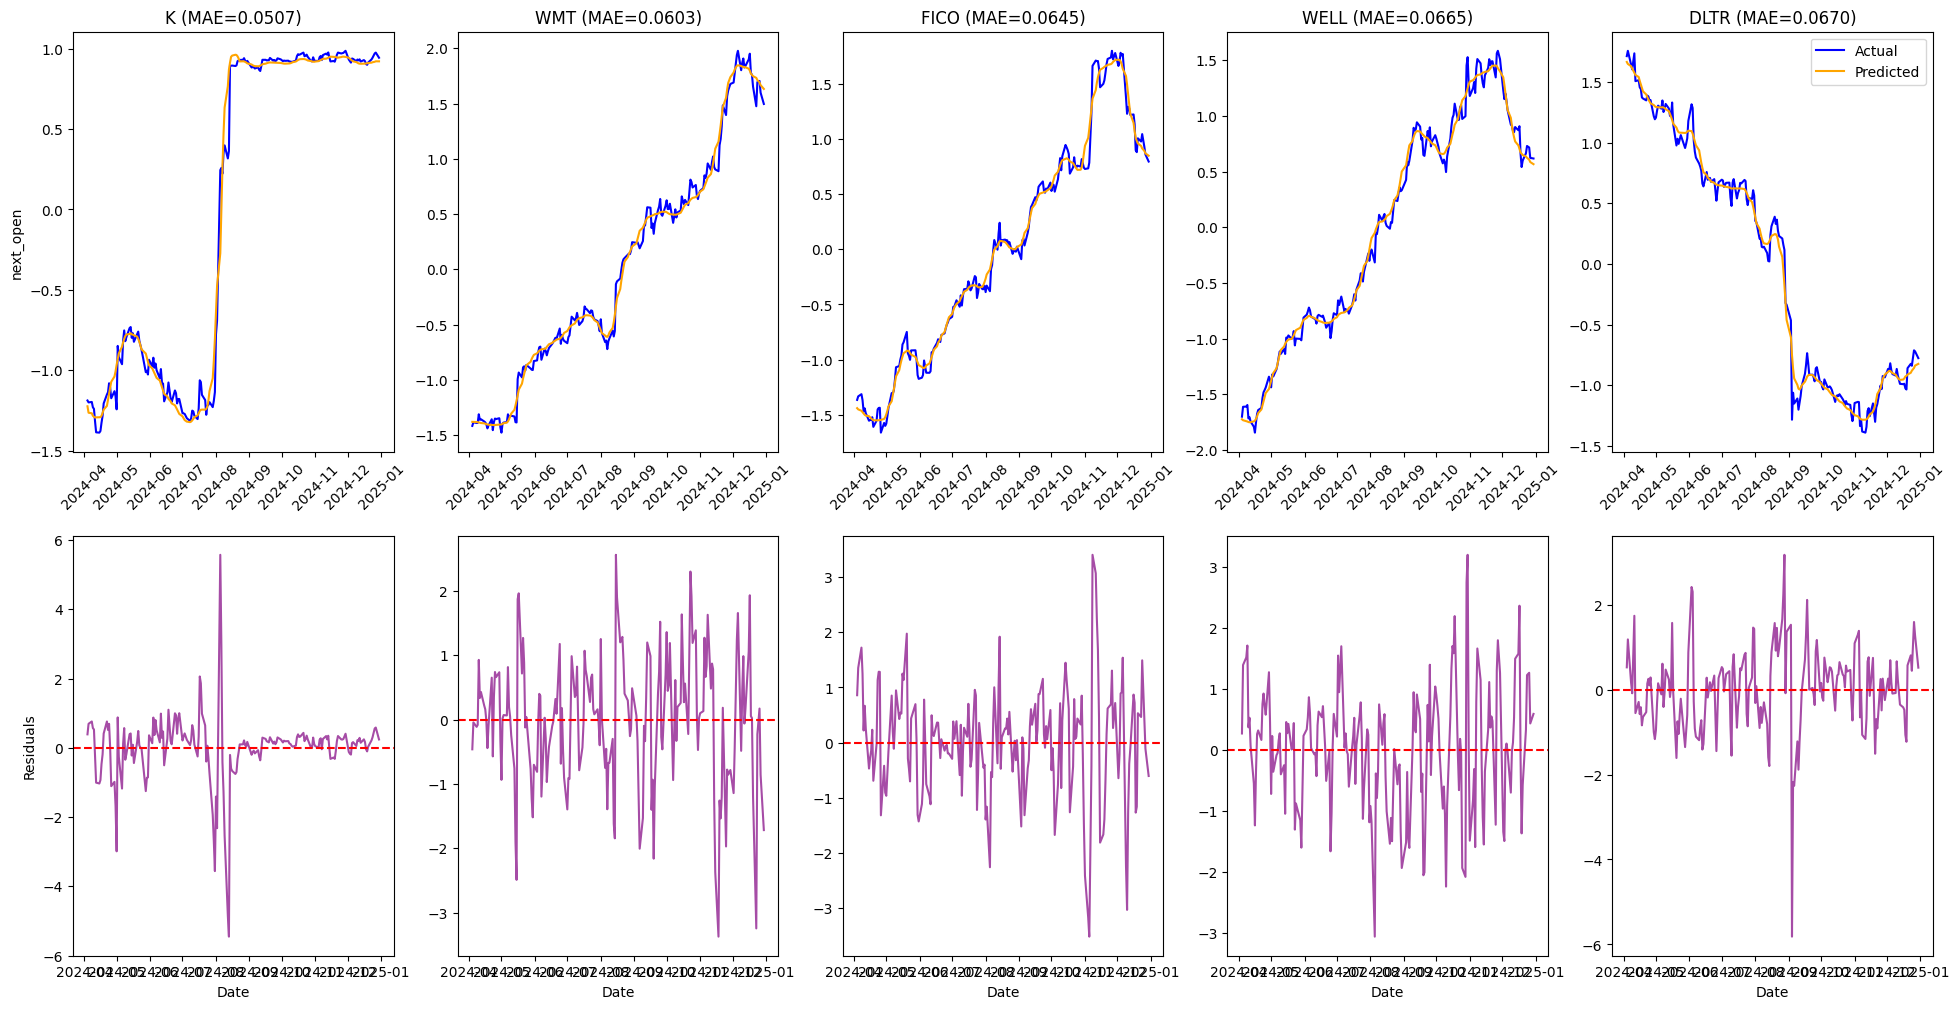

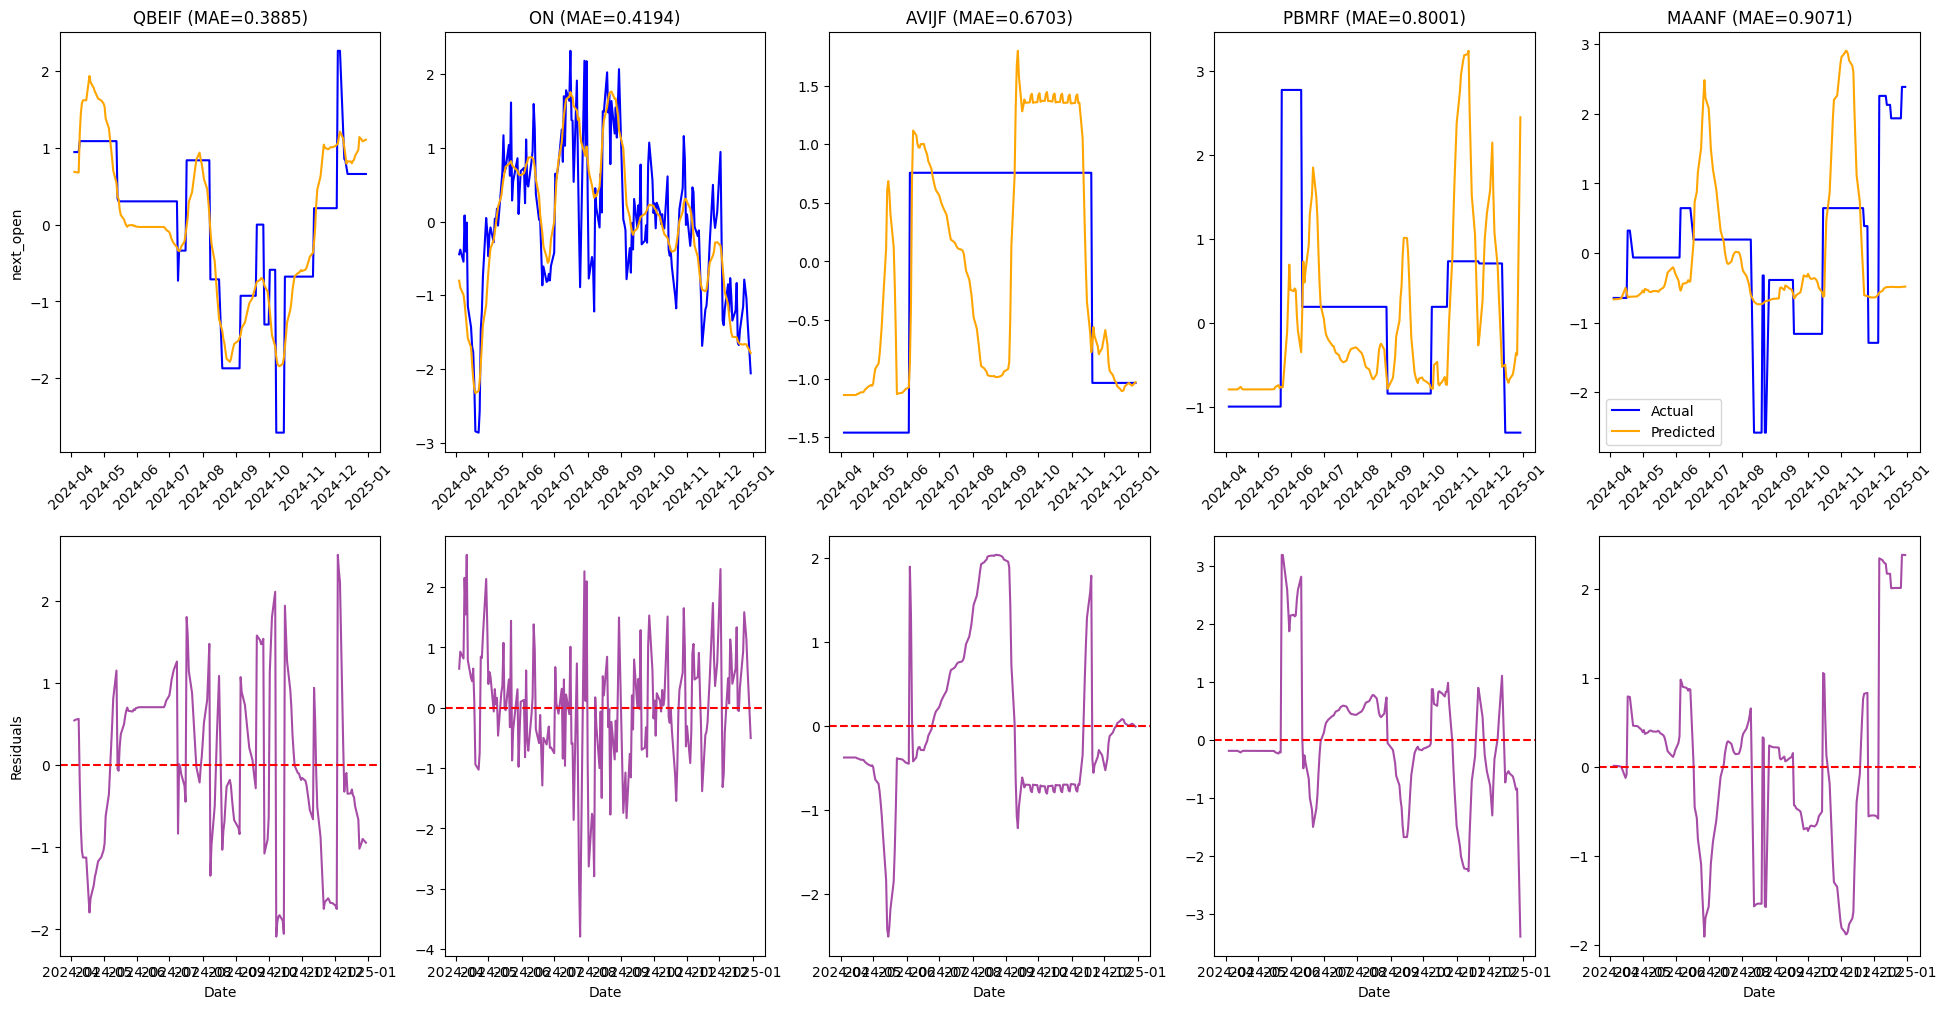

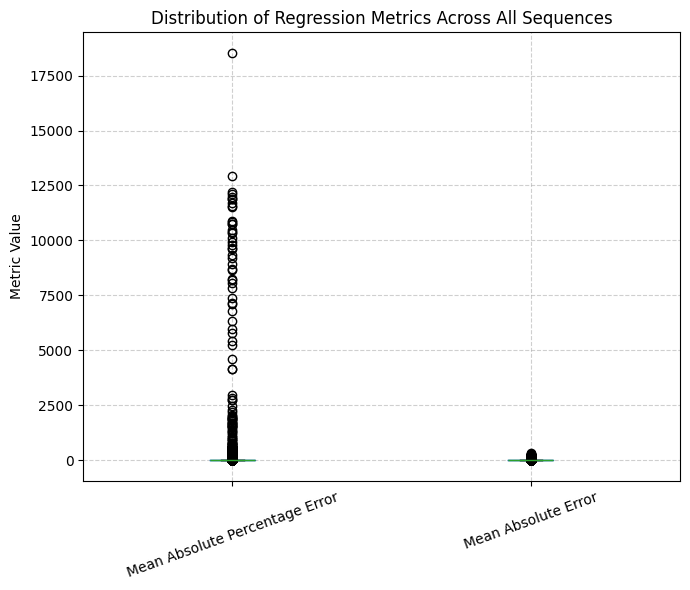

In [3]:
from S4_Model_Validation import S4_Model_Validation

(regression_res_df, regression_res_full_df_seq, regression_res_full_tickers_df_seq, 
 result_df, result_df_no_dupe, results_df_standardized_no_dupe) = S4_Model_Validation(args, None)

### Ticker-Level Metric Comparisons ###

2026-01-24 11:32:08 [INFO] Evaluating Metrics Distribution Across Tickers...
2026-01-24 11:32:08 [INFO] Combined metrics summary table:


,Mean Absolute Percentage Error,Bias (Mean Error),Correlation
mean,2.227410,1.406366,0.120681
median,1.356697,0.442287,0.203856
std,8.295084,3.113310,0.584749
min,0.000000,-0.000023,-0.981744
max,138.877274,41.052383,0.954588
25th_percentile,0.879153,0.040619,-0.434643
75th_percentile,2.083562,1.403710,0.649160
IQR,1.204409,1.363091,1.083803


2026-01-24 11:32:08 [INFO] Plotting combined regression metric plots for Mean Absolute Percentage Error across tickers...
2026-01-24 11:32:10 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-24 11:32:10 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


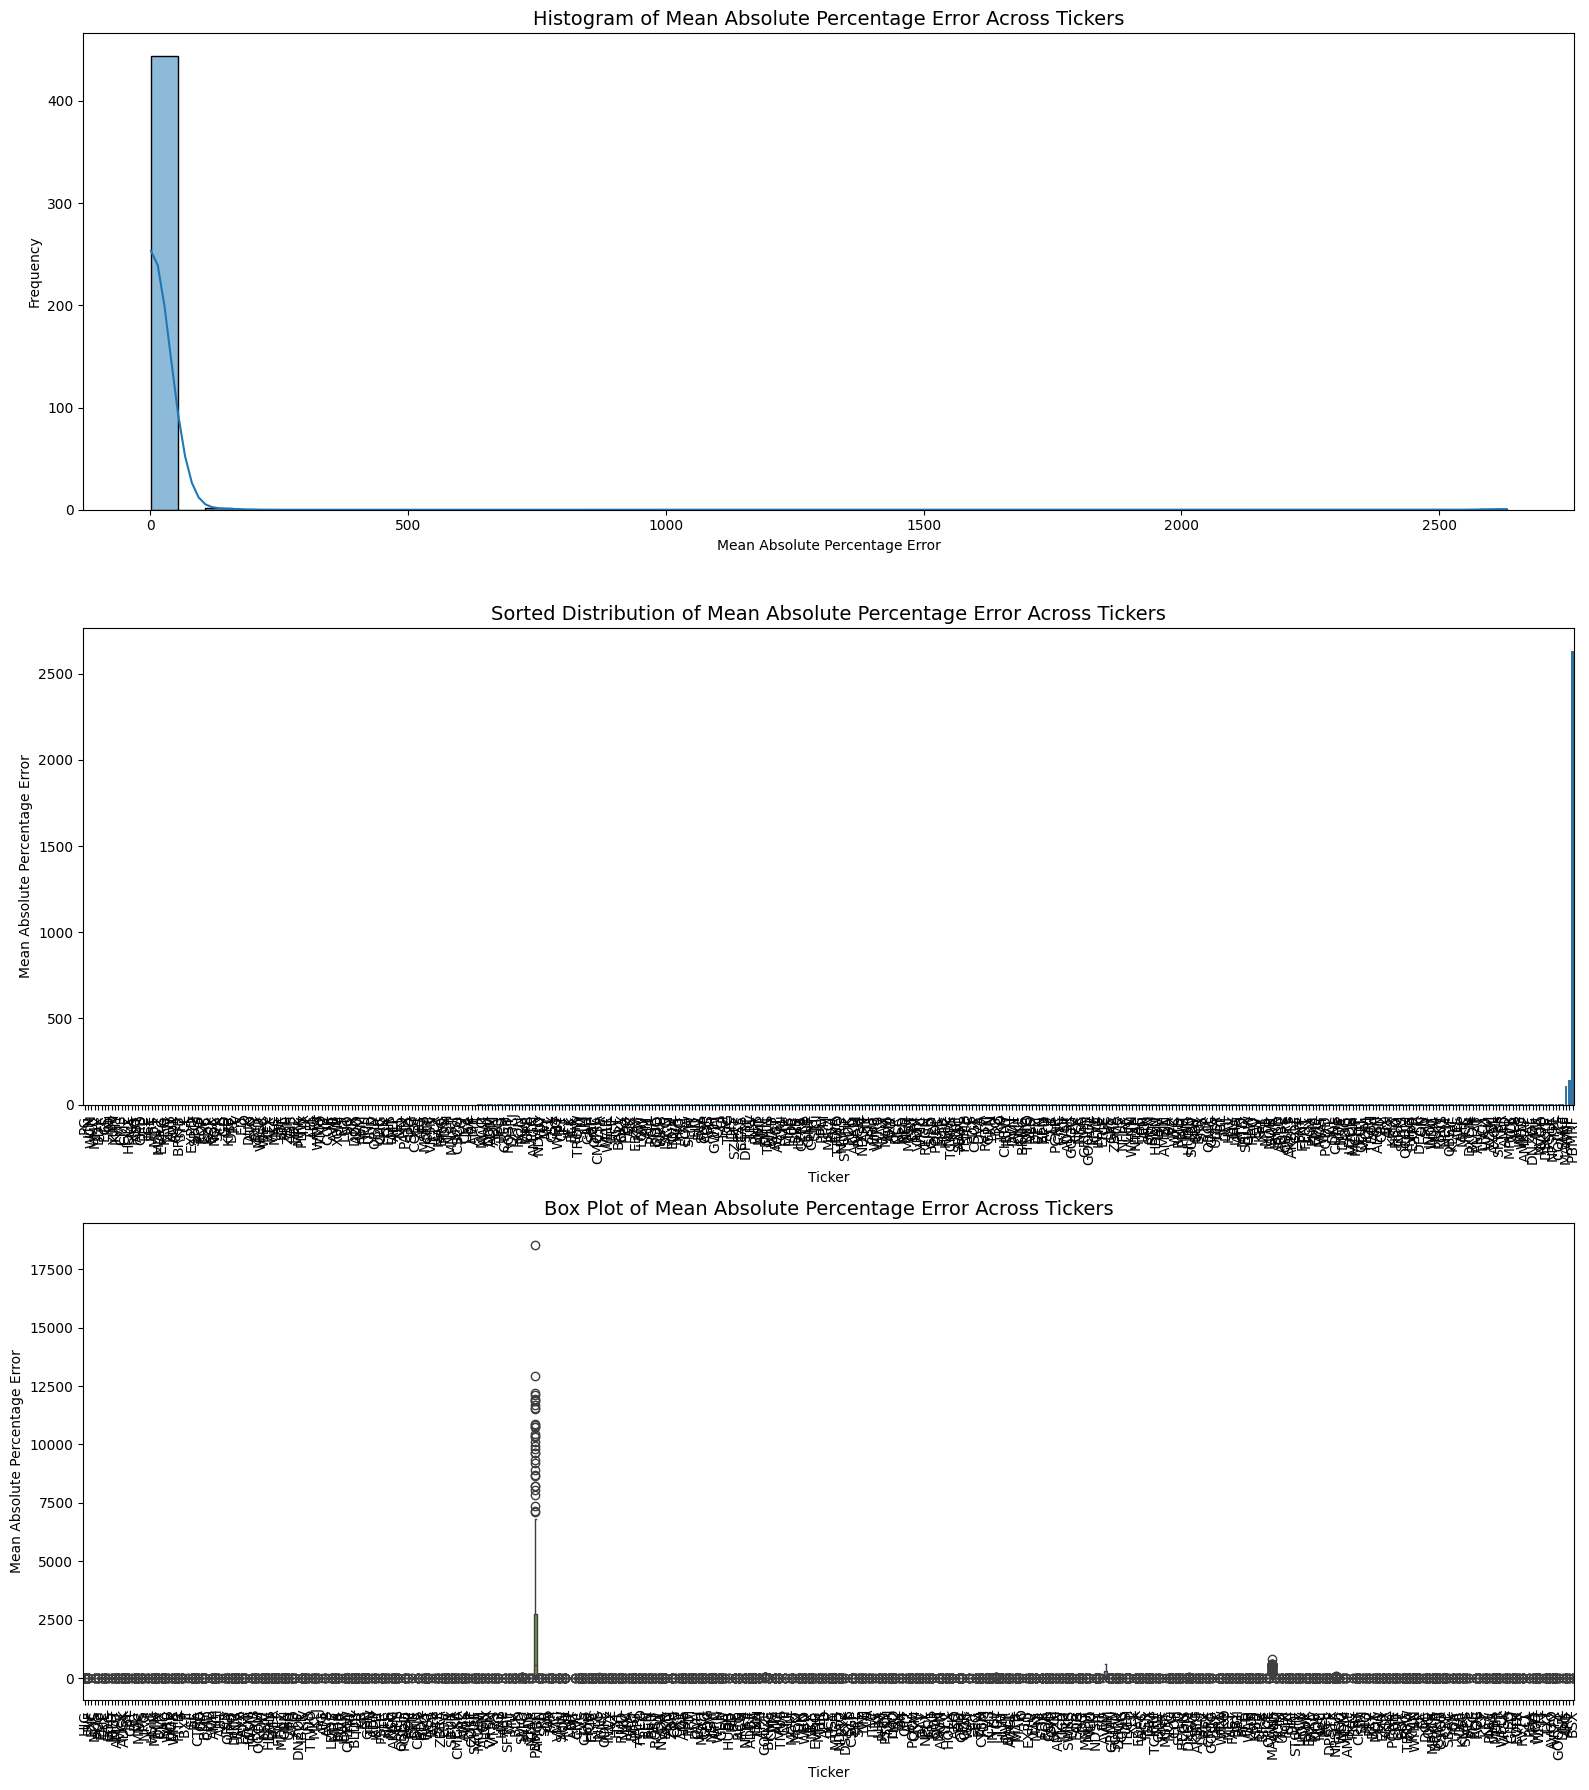

2026-01-24 11:32:22 [INFO] Plotting combined regression metric plots for Bias (Mean Error) across tickers...
2026-01-24 11:32:25 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-24 11:32:25 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


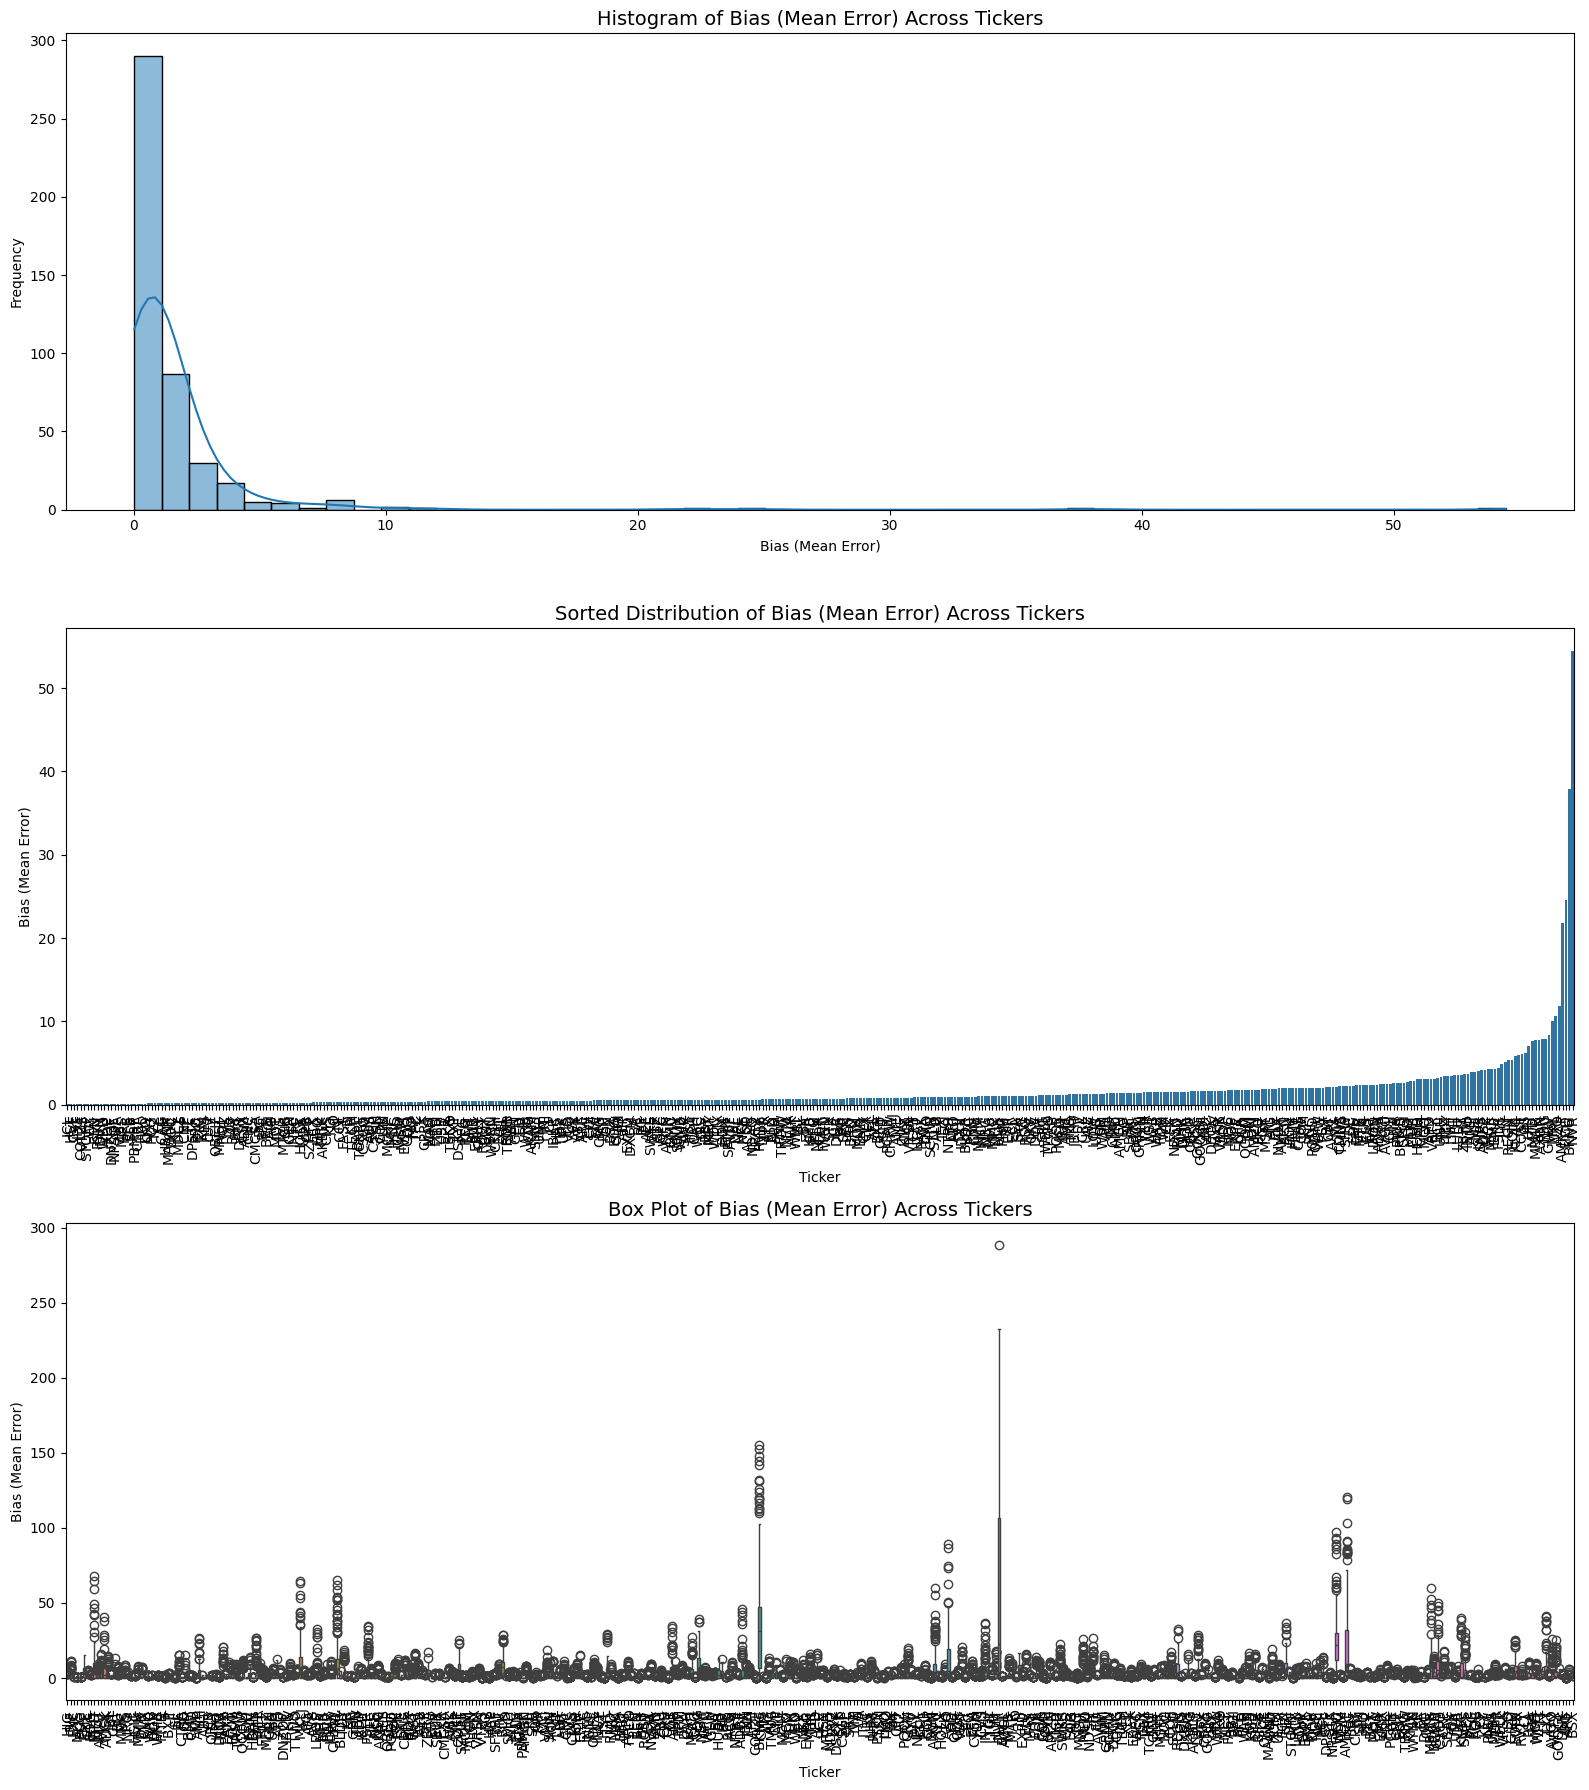

2026-01-24 11:32:37 [INFO] Plotting combined regression metric plots for Correlation across tickers...
2026-01-24 11:32:39 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-01-24 11:32:39 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


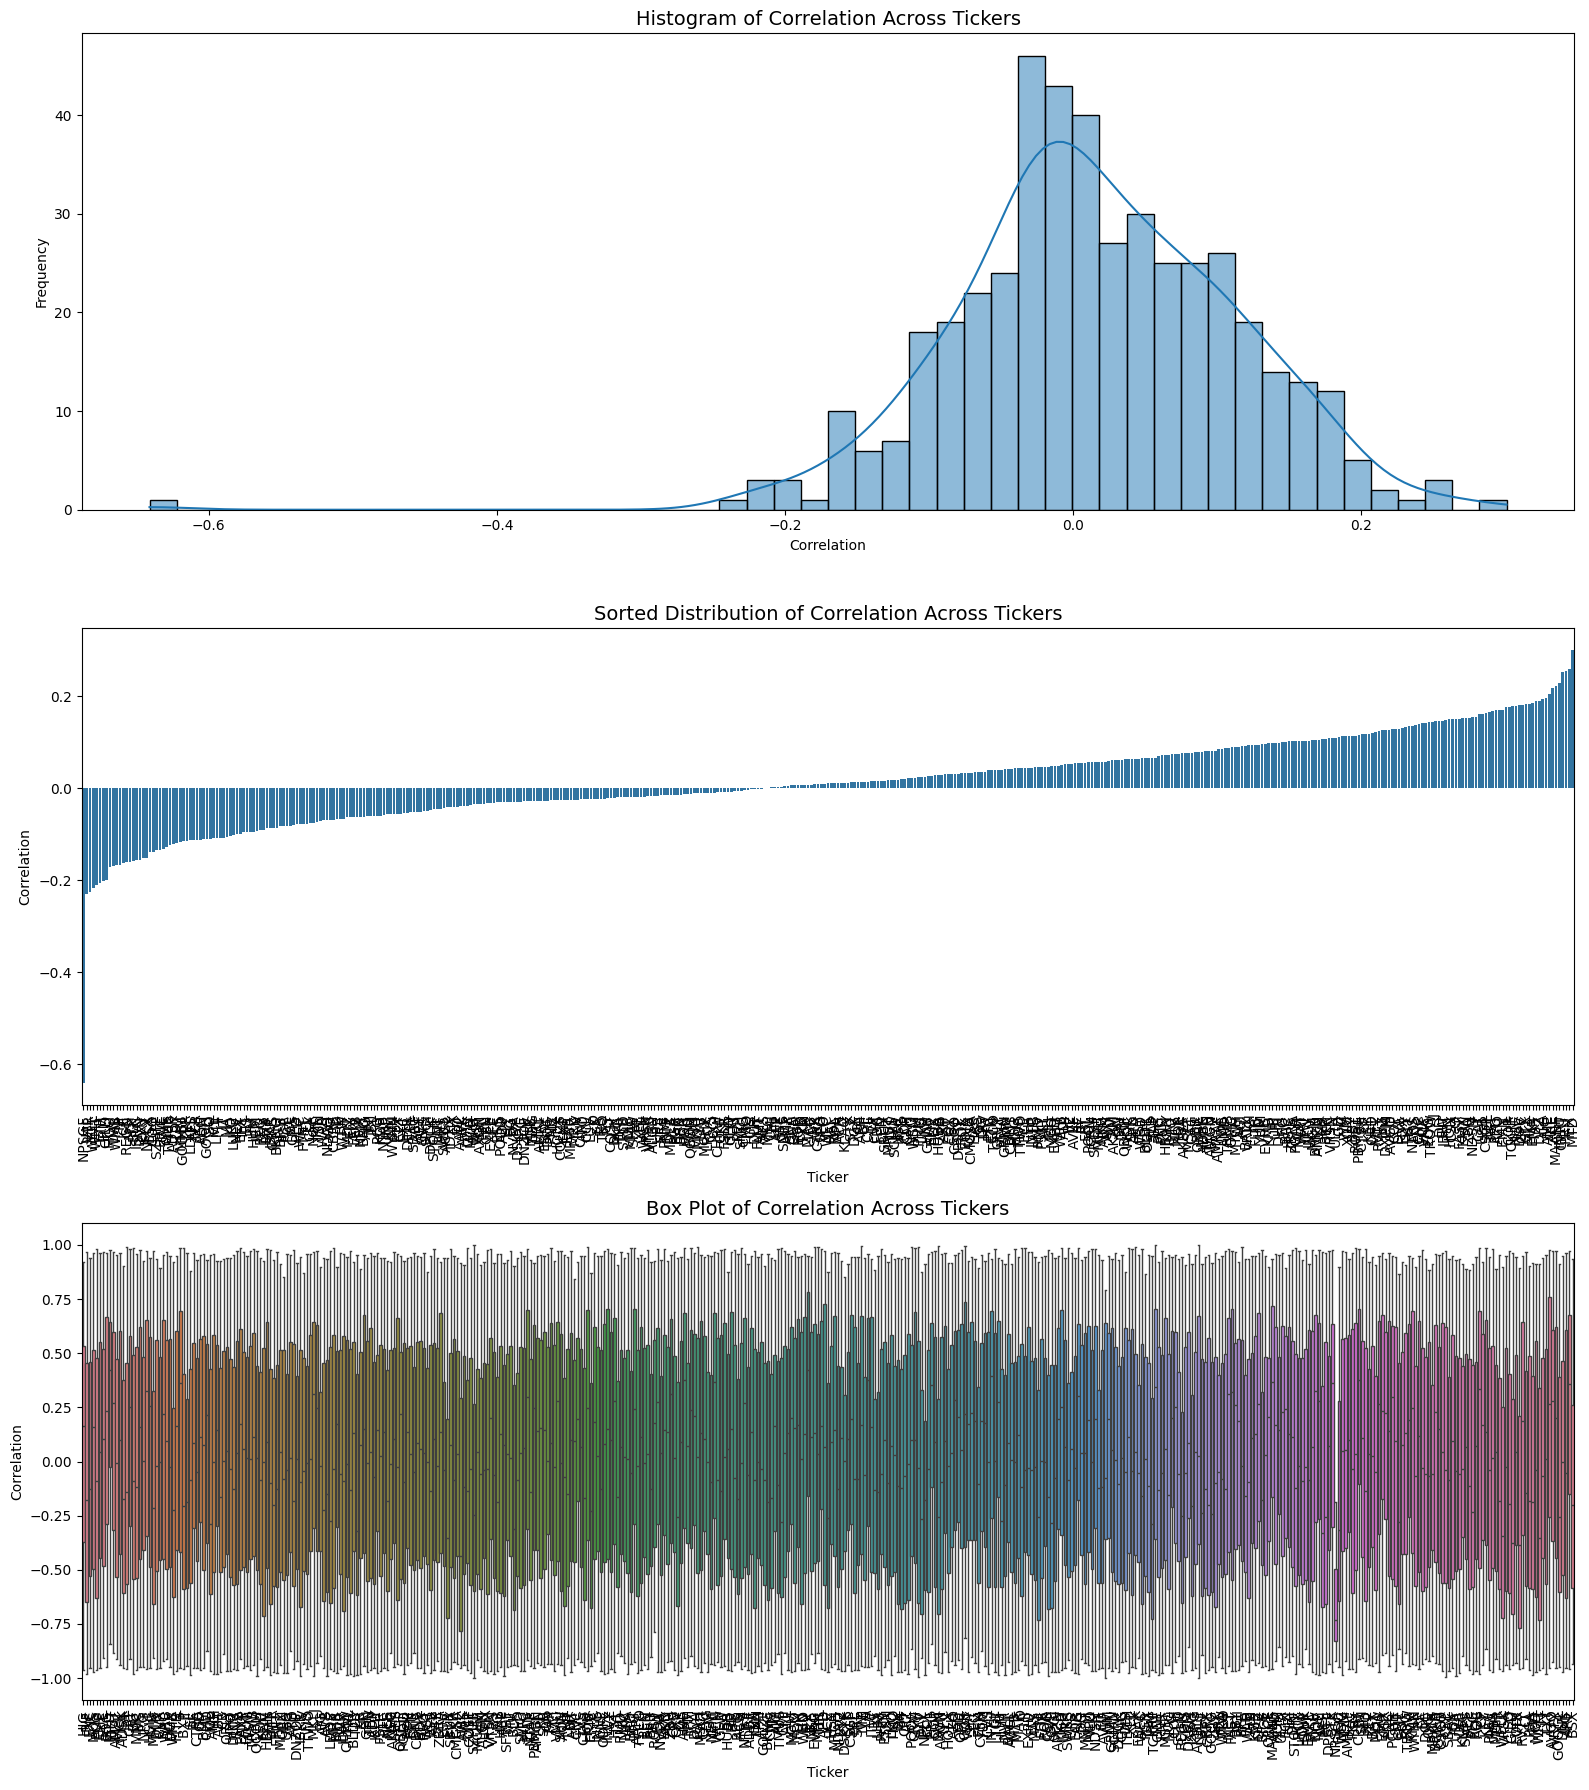

,Mean Absolute Percentage Error,Bias (Mean Error),Correlation
mean,2.227410,1.406366,0.120681
median,1.356697,0.442287,0.203856
std,8.295084,3.113310,0.584749
min,0.000000,-0.000023,-0.981744
max,138.877274,41.052383,0.954588
25th_percentile,0.879153,0.040619,-0.434643
75th_percentile,2.083562,1.403710,0.649160
IQR,1.204409,1.363091,1.083803


In [4]:
from S4_Model_Validation import S4_evaluate_metrics_distribution_across_tickers

S4_evaluate_metrics_distribution_across_tickers(args, regression_res_full_tickers_df_seq, )

### Bucket Level Metrics Calculations ###

2026-01-24 11:32:51 [INFO] Evaluating Metrics Distribution Across Buckets in column 'Bucket'...
2026-01-24 11:32:51 [INFO] Ticker to Bucket
2026-01-24 11:32:51 [INFO] Saved Ticker to Bucket mapping to ../data/processed_data/ticker_volatility_buckets_tickers_448_7_Channels_with_temporal_tape_v2.json


Bucket                                          0          1          2  \
Metric                         Stat                                       
Bias (Mean Error)              count    90.000000  89.000000  89.000000   
                               mean      0.223047   0.499723   0.789667   
                               std       0.113497   0.201173   0.299941   
                               min       0.027812   0.101628   0.275726   
                               25%       0.146241   0.406068   0.576368   
                               50%       0.189271   0.472874   0.717928   
                               75%       0.287820   0.586703   0.942424   
                               max       0.601590   1.542139   1.609357   
Correlation                    count    90.000000  89.000000  89.000000   
                               mean      0.025926   0.033453   0.009102   
                               std       0.110771   0.093073   0.100157   
                               min      -0.641177  -0.166807  -0.226014   
                               25%      -0.025890  -0.023923  -0.055666   
                               50%       0.025096   0.030166   0.008007   
                               75%       0.093340   0.103481   0.078208   
                               max       0.253415   0.255883   0.205010   
Mean Absolute Percentage Error count    90.000000  89.000000  89.000000   
                               mean     33.660174   1.523653   1.503396   
                               std     277.483076   0.474349   0.361629   
                               min       0.937504   0.884660   0.920395   
                               25%       1.241811   1.168491   1.239690   
                               50%       1.528346   1.421320   1.399173   
                               75%       1.928450   1.756318   1.778810   
                               max    2630.916504   3.128531   2.585648   

Bucket                                        3          4  
Metric                         Stat                         
Bias (Mean Error)              count  89.000000  90.000000  
                               mean    1.411165   4.930008  
                               std     0.454230   7.375033  
                               min     0.200891   0.155394  
                               25%     1.112098   2.158486  
                               50%     1.372362   3.077249  
                               75%     1.748099   4.414872  
                               max     2.411603  54.451122  
Correlation                    count  89.000000  90.000000  
                               mean    0.003692   0.001818  
                               std     0.084114   0.093316  
                               min    -0.230962  -0.171052  
                               25%    -0.045102  -0.060355  
                               50%    -0.000706  -0.002288  
                               75%     0.052036   0.057598  
                               max     0.258988   0.300790  
Mean Absolute Percentage Error count  89.000000  90.000000  
                               mean    1.806107   1.817587  
                               std     0.748127   0.560305  
                               min     0.911449   0.995235  
                               25%     1.383889   1.447269  
                               50%     1.629281   1.703385  
                               75%     2.007807   2.078944  
                               max     6.567575   4.001348

2026-01-24 11:33:05 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
c:\Users\yinki\OneDrive\NUS\BT4101\fyp-kiat\ML_Core\src\S4_Model_Validation.py:798: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Bucket', y='Value', data=bucket_df, palette='viridis')
2026-01-24 11:33:05 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


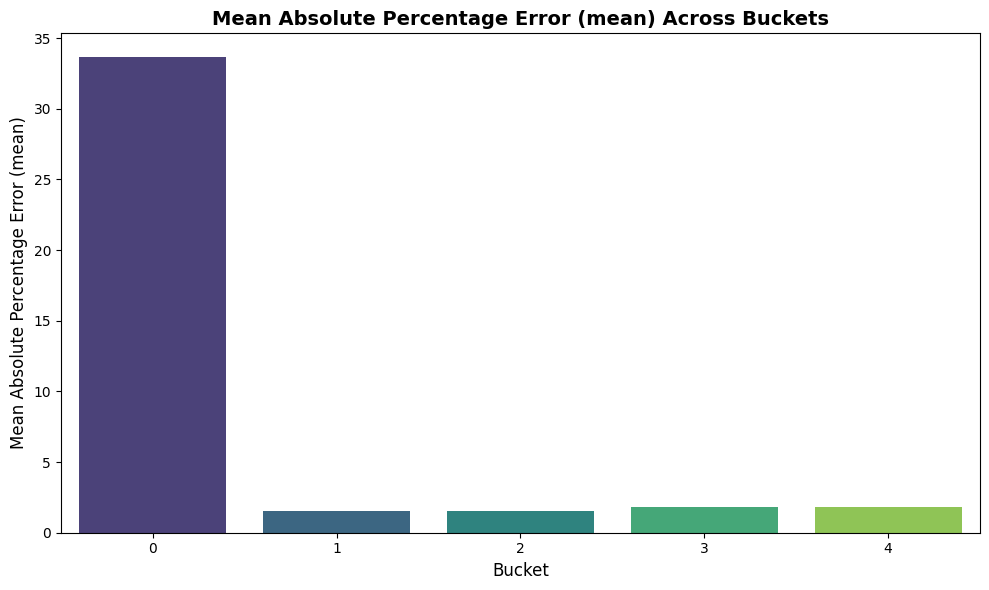

2026-01-24 11:33:05 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
c:\Users\yinki\OneDrive\NUS\BT4101\fyp-kiat\ML_Core\src\S4_Model_Validation.py:798: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Bucket', y='Value', data=bucket_df, palette='viridis')
2026-01-24 11:33:05 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


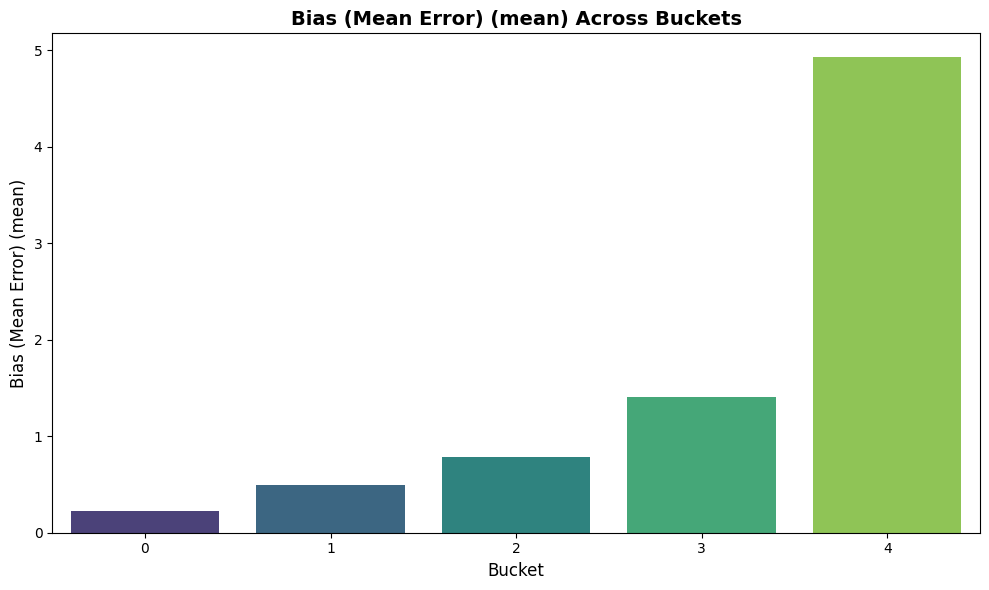

2026-01-24 11:33:05 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
c:\Users\yinki\OneDrive\NUS\BT4101\fyp-kiat\ML_Core\src\S4_Model_Validation.py:798: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Bucket', y='Value', data=bucket_df, palette='viridis')
2026-01-24 11:33:05 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


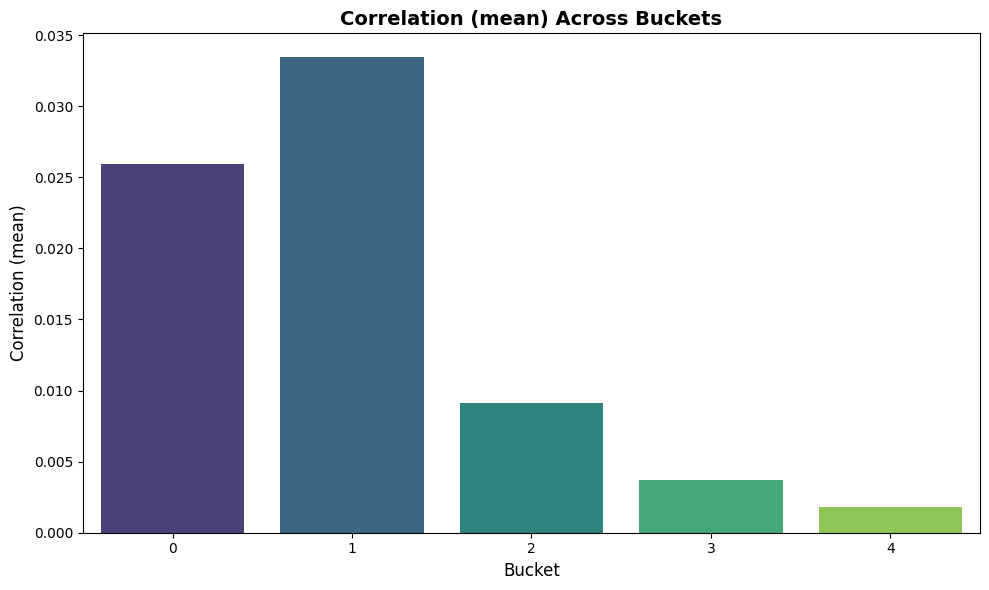

In [5]:
from S4_Model_Validation import volatility_bucket_function, S4_evaluate_metrics_distribution_across_buckets, plot_metric_across_buckets

metrics_to_evaluate = ['Mean Absolute Percentage Error', 'Bias (Mean Error)', 'Correlation']
labels_to_evaluate = ['mean', 'mean', 'mean']

### Bucket Level Metrics Calculations ###
summary_df = S4_evaluate_metrics_distribution_across_buckets(args, labels_df=result_df_no_dupe, 
                                                                    regression_res_full_tickers_df=regression_res_full_tickers_df_seq, 
                                                                    bucket_column_func = volatility_bucket_function, 
                                                                    metrics_to_evaluate = ['Mean Absolute Percentage Error', 'Bias (Mean Error)', 'Correlation'], 
                                                                    labels_to_evaluate = ['mean', 'mean', 'mean'],
                                                                    save_buckets = True,
                                                                    save_buckets_path = args.regression.S3.bucket_mapping_jsons.volatility.buckets,
                                                                    n_buckets = 5)



for metric in metrics_to_evaluate:
    plot_metric_across_buckets(args, summary_df, metric)

In [6]:
from S4_Model_Validation import plot_ticker_grid

result_df_no_dupe

,Date,Ticker,next_open,next_open_predicted
0,2024-04-04,A,141.339996,144.579727
1,2024-04-04,AAPL,168.820007,171.072510
2,2024-04-04,ABT,110.110001,110.611252
3,2024-04-04,ACGL,91.089996,93.770813
4,2024-04-04,ACN,330.470001,325.997498
...,...,...,...,...
83584,2024-12-30,XEL,67.589996,67.772400
83585,2024-12-30,XOM,105.760002,106.153748
83586,2024-12-30,YUM,133.520004,134.220947
83587,2024-12-30,ZBH,105.400002,106.806870


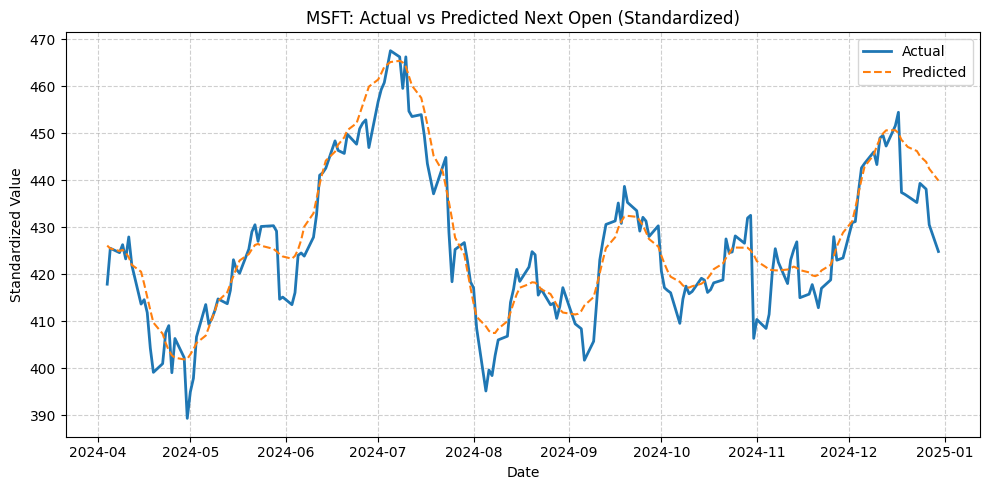

In [7]:
import matplotlib.pyplot as plt

df_msft = result_df_no_dupe.query("Ticker == 'MSFT'").sort_values('Date')

plt.figure(figsize=(10,5))
plt.plot(df_msft['Date'], df_msft['next_open'], label='Actual', linewidth=2)
plt.plot(df_msft['Date'], df_msft['next_open_predicted'], label='Predicted', linestyle='--')
plt.title('MSFT: Actual vs Predicted Next Open (Standardized)')
plt.xlabel('Date')
plt.ylabel('Standardized Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




In [8]:
# import matplotlib.pyplot as plt
# import math
# import pandas as pd

# # Make sure Date is datetime
# result_df_no_dupe['Date'] = pd.to_datetime(result_df_no_dupe['Date'])

# # Get all unique tickers
# tickers = sorted(result_df_no_dupe['Ticker'].unique())

# # Grid setup
# n_tickers = len(tickers)
# n_cols = 10
# n_rows = math.ceil(n_tickers / n_cols)

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.5*n_rows), sharex=False, sharey=False)
# axes = axes.flatten()  # flatten to easily index axes

# for i, ticker in enumerate(tickers):
#     ax = axes[i]
#     df_t = result_df_no_dupe.query("Ticker == @ticker").sort_values('Date')

#     ax.plot(df_t['Date'], df_t['next_open'], label='Actual', linewidth=1.5)
#     ax.plot(df_t['Date'], df_t['next_open_predicted'], label='Predicted', linestyle='--', linewidth=1)
#     ax.set_title(ticker, fontsize=9)
#     ax.grid(True, linestyle='--', alpha=0.4)
    
#     # optional: hide x labels for top rows for readability
#     if i < (n_rows - 1) * n_cols:
#         ax.set_xticklabels([])

# # Remove unused subplots if tickers < grid size
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# # Global legend and layout
# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=2)
# fig.suptitle('Actual vs Predicted Next Open (Standardized) per Ticker', fontsize=14)
# plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show()


In [9]:
# import matplotlib.pyplot as plt

# tickers_plot = ['MSFT', 'NEE', 'AGI']

# fig, axes = plt.subplots(1, len(tickers_plot), figsize=(20, 5), sharex=False, sharey=False)

# for i, ticker in enumerate(tickers_plot):
#     df_t = result_df_no_dupe.query(f"Ticker == '{ticker}'").sort_values('Date')
    
#     axes[i].plot(df_t['Date'], df_t['next_open'], label='Actual', linewidth=2)
#     axes[i].plot(df_t['Date'], df_t['next_open_predicted'], label='Predicted', linestyle='--')
#     axes[i].set_title(f"{ticker}: Actual vs Predicted", fontsize=10)
#     axes[i].set_xlabel('Date')
#     axes[i].grid(True, linestyle='--', alpha=0.6)

# axes[0].set_ylabel('Price')
# axes[-1].legend(loc='upper right')

# plt.tight_layout()
# plt.show()
